Hasta ahora nos hemos concentrado en la **POBLACIÓN**:

- Hemos asumido que podemos observar toda la población objeto de un **experimento aleatorio**

- Construimos un *modelo probabilistico* para enmarcar el rol de la *incertidumbre* en el *outcome final* del experimento aleatorio.

- En general todo se resume en **caracterizar la distribución (marginal / conjunta) de probabilidad**

- Pero ... **es siempre posible observar la población objetivo** de un experimento aleatorio? / tenemos acceso a las observaciones de un experimento aleatorio *socio-económico* asociadas a toda la población?

    - Generalmente la respuesta es **NO**

# Inferencia

* Necesitamos apelar entonces al *razonamiento inductivo* $\Rightarrow$ **INFERENCIA** a partir de una **muestra** la población

* Para poder hacer valida nuestra *inferencia* la selección de la muestra no puede ser realizada de manera arbitraria.

## Muestreo aleatorio

1. Se debe determinar el *experimento o proceso aleatorio* y su *población objetivo* sobre los cuales se quiere hacer una *análisis de inferencia*.

2. Cada observación recogida de los individuos parte de la muestra es **una posible realización de una variable aleatoria** que resume los posibles resultados del experimento o proceso aleatorio.

3. Se diseña el mejor método de muestreo para *seleccionar entre la población una muestra de tamaño* $N$:
    
    - *Muestreo aleatorio simple*: 
    
        * Selección del individuo parte de la muestra es tal que dentro de la población su probabilidad de haber sido seleccionado es la misma que la de cualquier otro individuo.

        * Observación del individuo $i$ no provee información del valor de la variable aleatoria para cualquier otro individuo $j$ dentro de la población, es decir, la variable aleatoria que generó la observacion del individuo $i$ es **independiente** de la variable aleatoria que generó la observacion del individuo $j$.  

    $\Rightarrow$ cada observación proviene de la realización de variables aleatorias con **independientes** y con **identica distribución** (*iid*).

### Ejemplo: Parte 1

- Población objetivo: *Individuos con 25 o más años de edad que participan en el mercado laboral en Colombia*.

- Proceso aleatorio: *Pago de salario mensual*

- Variable aleatoria: $\color{blue}W_{i}(\omega) := \text{ cientos de miles de \$ por trabajo mensual realizado por el individuo } i$

- **Muestra**: 

    * **Subconjunto de la población** para la cual se tienen las realizaciones de la variable aleatoria: $W_{1},W_{2},\ldots,W_{N}$. 

    * DANE, GEIH - 2012: vamos a "cargar" nuestra muestra. El formato del archivo que contiene la muestra es ``.dta`` (archivo de *Stata*). Utilizamos la función ``read_dta()`` del paquete ``haven`` en ``R``:

In [2]:
# Si no tienen instalado el paquete haven, en la consola de R Studio
# ejecuten el comando:
# install.packages("haven")

# Cargamos la librerías
library(haven)
library(tidyverse)
# Ahora utilizamos la función read_dta() para cargar nuestro archivo
# ADVERTENCIA: La base de datos original debe estar en el mismo directorio o
# carpeta en el que esta trabajando su código. De otra forma, debe utilizar 
# toda la ruta al archivo al interior de la función
muestra <- read_dta("hh2012_data.dta", encoding = "latin1") # Usuarios Mac
# muestra <- read_dta("hh2012_data.dta", encoding = "UTF-8") # Usuarios PC
# Filtramos la muestra para nuestra población objetivo y cambiamos el nombre
# de la variable que contiene la medición de nuestra variable aleatoria
muestra <- 
    muestra %>%
    filter(participacion == 1) %>%
    mutate(id = 1:nrow(.)) %>%
    rename(salario_mensual = ing_laboral) %>%
    select(id, salario_mensual)

#Calculamos el tamaño de nuestra muestra    
N_muestra <- nrow(muestra)
sprintf("El tamano de la muestra es N = %6.0f", N_muestra)

-- Attaching packages --------------------------------------- tidyverse 1.3.2 --
v ggplot2 3.3.6     v purrr   0.3.4
v tibble  3.1.8     v dplyr   1.0.9
v tidyr   1.2.0     v stringr 1.4.1
v readr   2.1.2     v forcats 0.5.2
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()


[1] "El tamano de la muestra es N = 293346"

## El promedio muestral

**Queremos acercarnos o hacer *inferencia* acerca del posible valor del valor medio en la población $\color{red}(\mu_{W})$**. *Utilizamos como aproximación el promedio muestral*: promedio simple de las observaciones de nuestra variable aleatoria dentro de la muestra:

$$\color{red}\bar{W} =  \frac{W_{1} + W_{2} + \cdots + W_N}{N}$$

Aunque no conocemos la distribución de las variables aleatorias dentro de la población, el **muestreo aleatorio** nos permite decir que:

1. Cada $w_i$ es la realizacion de la varaiable aleatoria $W_i$ $\color{red}\Rightarrow\bar{W}\text{ es una variable aleatoria tambien!!}$  

2. La distribución de $W_i$ es **idéntica** a la distribución de cualquier otro $W_j$, es decir **sus momentos, incluidos sus valores medios y sus varianzas (que desconocemos), en la población deben ser iguales**:

    \begin{gather}
    \color{blue}E[W_i] = E[W_j] = \mu_{W}\\[0.5cm]
    \color{blue}V[W_i] = V[W_j] = \sigma_{W}^2
    \end{gather}

    para cualquiera $i,j$ en $1,2,\ldots,N$.

3. Podemos establecer el valor medio del promedio muestral:

    \begin{gather*}
    E[\bar{W}] = \frac{\overbrace{E[W_{1}]}^{\color{blue}=\mu_{W}} + \overbrace{E[W_{2}]}^{\color{blue}=\mu_{W}} + \cdots + \overbrace{E[W_N]}^{\color{blue}=\mu_{W}}}{N} = \frac{N\mu_{W}}{N}\\[0.5cm]
    \color{red}\mu_{\bar{W}}\equiv E[\bar{W}] = \mu_{W}
    \end{gather*}

4. Y como **$W_i$ es independiente de $W_j$**, la varianza del promedio muestral se puede calcular como:

   \begin{gather*}
    V[\bar{W}] = \frac{1}{N^2}\overbrace{V[W_{1}]}^{\color{blue}=\sigma_{W}^2} + \overbrace{V[W_{2}]}^{\color{blue}=\sigma_{W}^2} + \cdots + \overbrace{V[W_N]}^{\color{blue}=\sigma_{W}^2} = \frac{N\sigma_{W}^2}{N^2}\\[0.5cm]
    \color{red}\sigma_{\bar{W}}^2\equiv V[\bar{W}] = \frac{\sigma_{W}^2}{N}
    \end{gather*}

    y su **desviación estándar debe ser**:

    $$\color{red}\sigma_{\bar{W}}\equiv\sqrt{V[\bar{W}]} = \frac{\sigma_{W}}{\sqrt{N}}$$ 
    

### Ejemplo: Parte 2

* Calculemos el promedio muestral de nuestra muestra:

In [10]:
W_bar_0 <- mean(muestra$salario_mensual)
sprintf("El promedio muestral del salario mensual es igual a %1.3f", W_bar_0)

[1] "El promedio muestral del salario mensual es igual a 7.525"

### Importancia del promedio muestral

* **No conocemos el valor medio poblacional de nuestra variable aleatoria**

* El promedio muestral es el **mejor estimador** lineal del valor medio poblacional:

    - Qué es un **estimador**: cualquier *estadística* calculada con la muestra es un estimador. Tratamos de aproximarnos con la muestra a algún *momento estadístico poblaional* desconocido en la población.  

    - En nuestro ejemplo supongan que quisieramos *estimar* el valor medio del salario mensual en nuestra poblacion $\mu_W \equiv E[W]$. Formalmente un estimador se define como

        $$\hat{\mu}_W = h(W_{1},W_{2},\ldots,W_{N})$$

       donde $h()$ es cualquier función. En nuestro caso particular

       $$\hat{\mu}_W = h(W_{1},W_{2},\ldots,W_{N}) = \frac{W_{1} + W_{2} + \cdots + W_N}{N} = \bar{W}$$

    - Resulta ser el *mejor estimador* porque:

        1.  *Insesgado*:
        
            $$\text{Sesgo} = \overbrace{E[\hat{\mu}_W]}^{\color{blue}=E[\bar{W}]} - E[W] = 0$$

        2. Tiene *mínima varianza*, es decir, su varianza $\frac{\sigma_W^2}{N}$ es la menor entre las varianzas de cualquier otro posible estimador (lineal) del valor medio.
    
    

## La distribución de probabilidad del promedio muestral

### Ejemplo: Parte 3
*Experimento mental*: Tomando como base nuestro ejemplo a partir de la muestra de la ``GEIH - 2012``, supongamos que el total de nuestra población es igual al total de la muestra ($293.346$ individuos).

1. Como muestristas decidimos tomar una **muestra aleatoria** de tamaño $N_{1} = 20.000$.

    * Criterio de aleatoriedad: *Lotería con $20.000$ ganadores*

        - Billete de lotería: número a partir del generador de números pseudoaleatorios basado en la distribuión uniforme ``runif()``.

        - Sorteo: *Se ordena la población de mayor a menor con respecto al número de billete de lotería. Se eligen los primeros $20.000$*. 

In [4]:
N_m <- 20000 # Tamaño de la muestra aleatoria

# Semilla inicial del generador de números aleatorios   
set.seed(1)
# Nuevo data frame que contiene la muestra aleatoria
muestra_1 <- muestra %>%
    # Creamos la variable lotería (números aleatorios):
    mutate(loteria = round(runif(N_muestra, 1, 300000))) %>%
    # Ordenamos el data frame de mayor a menor:
    arrange(loteria) %>%
    # Realizamos el sorteo:
    mutate(sorteo = 1:nrow(.)) %>%
    filter(sorteo <= N_m)

sprintf("El valor del promedio muestral del salario mensual, es igual a %1.2f", mean(muestra_1$salario_mensual))

[1] "El valor del promedio muestral del salario mensual, es igual a 7.49"

2. Tenemos la posibilidad de repetir la lotería $2000$ veces sin costo, cambiando el valor inicial de la semilla del generador de números pseudo aleatorios, y calcular cada vez el promedio muestral:

In [7]:
simulaciones <- 2000
# Inicializamos el vector en el que vamos a guardar cada calculo
# del promedio muestral del salario mensual
w_bar <- numeric(simulaciones)

# Utilizamos la estructura "for" para repetir el ejercicio 
# 1000 veces
for (i in 1:simulaciones) {
    set.seed(i)
    submuestra <- muestra %>%
        mutate(loteria = round(runif(N_muestra, 1, 300000))) %>%
        arrange(loteria) %>%
        mutate(sorteo = 1:nrow(.)) %>%
        filter(sorteo <= N_m)
  
    w_bar[i] = mean(submuestra$salario_mensual)
}

head(w_bar)

[1] 7.493200 7.597396 7.614418 7.608267 7.619229 7.533754

3. Sabemos que el valor medio de nuestra *población* es $\mu_{W} = 7.52$. Podemos corroborar que nuestro estimador, que es el promedio muestral, es **insesgado** si concluimos que $E[\bar{W}] = \mu_{W}$. Calculemos entonces el valor medio de nuestras $1000$ simulaciones, además del *sesgo* $(E[\bar{W}] - \mu_{W})$:

In [9]:
# 1. Calculamos el valor medio
E_W_bar <- mean(w_bar)
sprintf("El valor medio de nuestro estimador es %1.3f", E_W_bar)
# 2. Ahora el sesgo:
Sesgo <- E_W_bar - W_bar_0
sprintf("El sesgo de nuestro estimador es %1.3f", Sesgo)

[1] "El valor medio de nuestro estimador es 7.528"

[1] "El sesgo de nuestro estimador es 0.003"

4. Podemos entonces gráficar la densidad de los diferentes promedios mensuales:

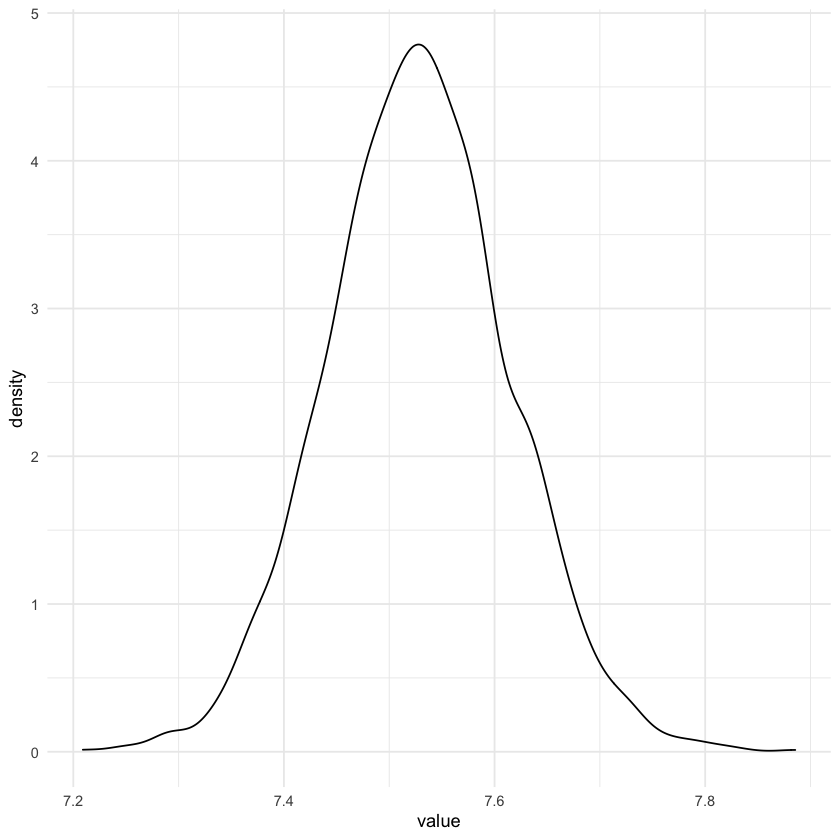

In [11]:
library(ggplot2)
# Convertimos el vector en tibble o data frame
w_bar <- as_tibble_col(w_bar)
# Graficamos la densidad
ggplot(w_bar, aes(x = value)) + geom_density() + 
    theme_minimal()

### Ley de los grandes números y Teorema del límite central

* Supuesto: **Muestra grande** ($\color{red}N\rightarrow\infty$)

#### Ley de los grandes números

* Bajo algunas condiciones generales y bajo el supuesto de *muestra grande*, con *muy alta probabilidad* **el promedio muestral de una variable aleatoria estará muy cerca del valor medio poblacional de dicha variable**.

* Cuando un número sufucientemente grande de variables aleatorias (*muestra grande*) son *promediadas* entre sí **los valores grandes tenderán a balancearse con los balores pequeños y dicho promedio estará muy cerca de su valor medio poblacional común**.

* Formalmente, utilizando nuestro ejemplo:

    - Condiciones generales:

        1. $\{W_{1},W_{2},\ldots,W_{N}\}$ son **variables aleatorias $iid$ con valor esperado o medio común** $\mu_{W}\equiv E[W]$.

        2. La probabilidad de que se realicen *valores extremos* es pequeña $(\sigma_{W}^2<\infty)$

    - Ley de los grandes números se expresa como:

        $$\color{red}\bar{W} = \frac{1}{N}(W_{1} + W_{2} + \cdots + W_{N})\xrightarrow{p}\mu_{W}$$

        y se lee "*$\bar{W}$ converge en probabilidad a $\mu_{W}$*" $\Rightarrow$ **Consistencia**: $\bar{W}$ es un estimador consistente de $\mu_{W}$ ya que, **a medida que el tamaño de muestra se incrementa $(N\rightarrow\infty)$, se acerca al valor medio poblacional de $W$ con probabilidad creciente hacia $1$**.

 ##### Ejercicio de simulación: Parte 1

Vamos a *comprobar* la ley de los grandes números:

1. Establecemos una secuencia creciente de tamaños de muestra:

In [35]:
# Primero creamos un vector que contenga los diferentes tamaños de muestra
NN <- c(50, 100, 250, 500, 1000, 2000, 5000, 10000)
# Veamos que hay en los primeros 10 elementos del vector NN
NN

[1]    50   100   250   500  1000  2000  5000 10000

2. Por cada tamaño de muestra en el vector ``NN``, vamos a simular $1000$ muestras de una variable aleatoria con media y varianza conocidas a partir del generador de números pseudoaleatorios de la distribución *Chi- cuadrado* ``chi-cuadrado`` con $2$ grados de libertad $(W\sim\chi_2^2)$. A cada una de estas muestras le cálculamos su *promedio muestral*. El valor medio y varianza poblacionales (conocidos) son iguales a:

    \begin{gather*}
    \mu_{W} \equiv E[W] = 2\\[0.3cm]
    \sigma_{W}^2 \equiv V[W] = 4 \Rightarrow \sigma_W = 2
    \end{gather*}

In [41]:
# Definimos el número de simulaciones
sim <- 1000
# Como tenemos que guardar los promedios de cada simulación por cada tamaño
# de muestra, iniciualizamos una matriz de ceros con tamaño 1000X5
W_bar_sim <- matrix(nrow = sim, ncol = length(NN))

for (N in NN) {
   for (m in 1:sim) {
    set.seed(m)
    W_bar_sim[m, which(NN == N)] = mean(rchisq(N, df = 2))
   }
}

# Miremos las primeras 10 filas de la matriz "W_bar_sim"
W_bar_sim[1:10, ]

1.721169,1.783667,2.002056,2.003176,1.973060,2.041075,2.011219,2.022439
1.905468,1.896313,1.994266,2.043614,1.984190,1.970494,2.004988,1.987910
1.552409,1.848826,2.053320,1.933882,2.004608,2.002537,2.011831,2.042354
1.996255,2.272293,1.992061,1.949121,1.969608,1.960786,1.982183,1.976088
2.072861,2.051461,2.107545,2.085735,2.118724,2.040884,1.997838,2.003242
1.761998,1.866122,1.807744,1.941832,2.040573,2.016872,2.016785,2.003931
2.137916,2.170337,2.206326,2.138690,2.043555,2.007729,1.967293,1.992726
2.312693,2.263778,2.067620,2.188911,2.103006,2.046852,2.027998,2.039593
1.778449,1.954152,1.883588,1.824776,1.944667,2.017617,2.037747,1.992743
1.773544,1.871453,2.217862,2.087969,2.066639,2.018241,2.015571,2.000761


In [45]:
# Ahora creamos el tibble o data frame 

# 1. Creamos un vector para construir la variable "tamaño de muestra"
# asociada a cada una de las simulaciones
tamano_muestra <- rep(NN, each = sim)

# 2. Creación del tibble
LLN_sample_mean <- tibble(tamano_muestra, as.vector(W_bar_sim))
colnames(LLN_sample_mean) <- c("Tamano_muestra", "Promedio_muestral")
head(LLN_sample_mean)

Tamano_muestra,Promedio_muestral
<dbl>,<dbl>
50,1.721169
50,1.905468
50,1.552409
50,1.996255
50,2.072861
50,1.761998


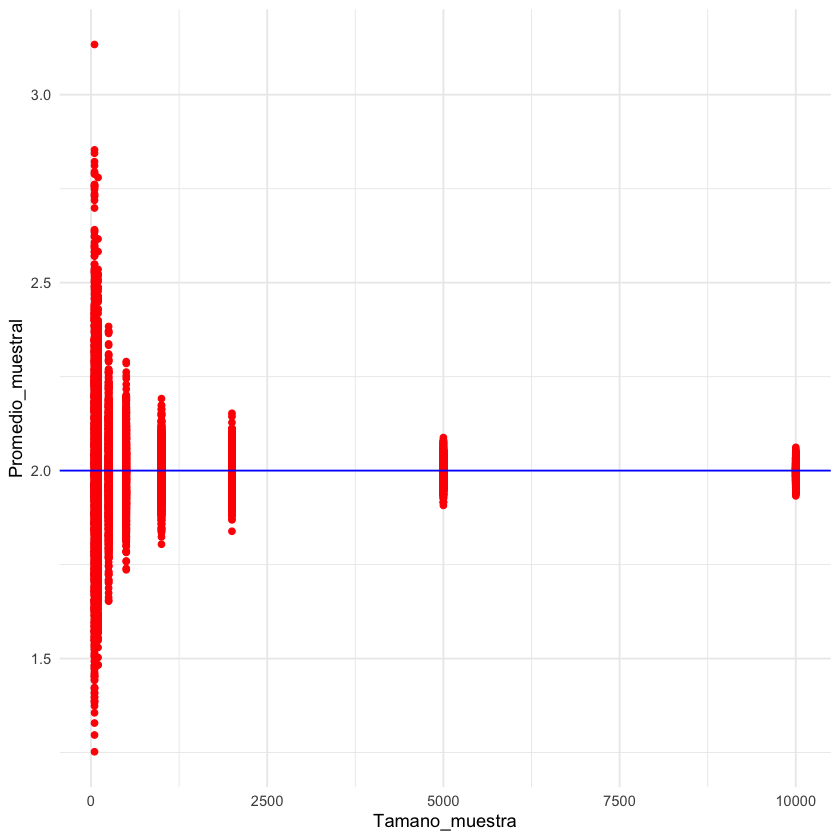

In [50]:
# Finalmente hacemos una gráfica que relaciona el tamaño de muestra con los
# promedios muestrales
ggplot(LLN_sample_mean, aes(Tamano_muestra, Promedio_muestral)) +
    geom_point(color = "red") + geom_hline(yintercept = 2, color = "blue") + 
    theme_minimal()

#### Teorema del límite central

* Bajo condiciones generales y bajo el supuesto de muestra grande, la **distribución del promedio muestral de variables aleatorias se aproxima a una distribución normal** *incluso si dichas variables aleatorias no se distribuyen normal*.

* Formalmente, utilizando nuestro ejemplo:

    - Condiciones generales:

        1. $\{W_{1},W_{2},\ldots,W_{N}\}$ son **variables aleatorias $iid$ con valor esperado o medio común** $\mu_{W}\equiv E[W]$.

        2. La probabilidad de que se realicen *valores extremos* es pequeña $(\sigma_{W}^2<\infty)$

    - El *teorema del límite central* se expresa como:

        $$\color{red}\bar{W}\sim\mathcal{N}\left(\mu_{W},\frac{\sigma_{W}^2}{N}\right)$$

##### Ejercicio de simulación: Parte 2

Vamos a utilizar los resultados de la primera parte de nuestro ejercicio de simulación:

1. A partir del tibble o data frame ``LLN_sample_mean``, hacemos gráficas de densidad *controlando por el tamaño de muestra*:

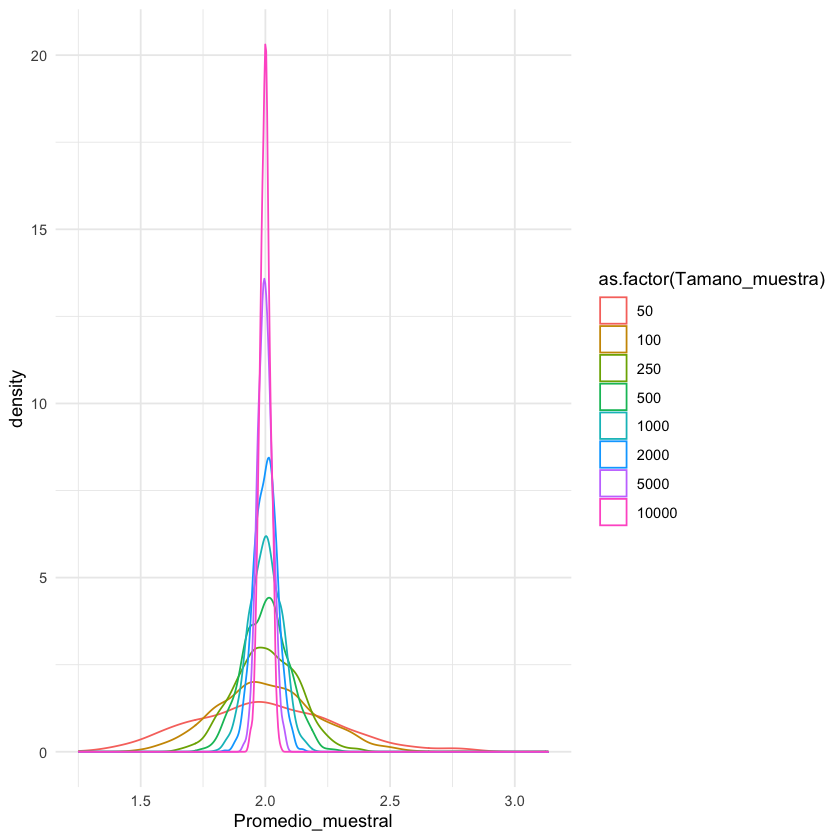

In [55]:
ggplot(LLN_sample_mean, aes(x = Promedio_muestral, color = as.factor(Tamano_muestra))) +
    geom_density() + theme_minimal()

### Inferencia sobre el valor medio

* **Interesados en el verdadero valor medio poblacional de alguna variable aleatoria**, hemos elegido al **promedio muestral** como el **mejor estimador** porque es:

    1. *Insesgado*

    2. el estimador con *mínima varianza*

    3. *Consistente*

* Sin embargo, *el promedio muestral es también una variable aleatoria* sujeta a incertidumbre, pero *sin importar la distribución original de la variable aleatoria original*, las implicaciones de *la ley de grandes números* y del *teorema del límite central* nos permite **caracterizar totalmente su distribución**

    - En nuestro ejemplo, para nuestras variables aleatorias $W_i$:

    $$\color{blue}\bar{W}\sim\mathcal{N}\left(\mu_{W},\frac{\sigma_{W}^2}{N}\right)$$

    - Si *estandarizamos el promedio muestral*:

    $$\color{blue}\frac{\bar{W} - \mu_{W}}{\frac{\sigma_{W}}{\sqrt{N}}}\sim\mathcal{N}\left(0,1\right)$$

#### Inferencia a partir de una prueba de hipótesis sobre el valor medio

* Volvamos a nuestro ejemplo:

    1. Recuerden: **$\mu_{W}$ es desconocido** pero podemos *hipotetizar acerca de su valor verdadero*. **Prueba de hipótesis**:

        \begin{align*}
        \color{red}H_0:\;\mu_{W} &\color{red}= \mu_{W,0}\;\;\text{(Hipotesis nula)}\\[0.3cm]
        \color{red}H_1:\;\mu_{W} &\color{red} \gtreqqless\mu_{W,0}\text{(Hipotesis alternativas)}
        \end{align*} 

    2. **$\sigma_{W}^2$ es también desconocido** pero podemos *aproximar la incertidumbre poblacional, a partir de la incertidumbre muestral*, es decir, elegimos como estimador de la varianza poblacional, a la varianza muestral:

        \begin{gather*}
        \color{blue}\hat{\sigma_{W}^2}\equiv s_{W}^2 = \frac{1}{N-1}\sum_{i=1}^{N}\,(W_{i}-\bar{W})^2\\[0.3cm]
        \color{blue}\hat{\sigma_{W}}\equiv s_{W} = \sqrt{s_{W}^2}
        \end{gather*}

        Definiendo el error estándar del promedio muestral como $\color{blue}SE(\bar{W})\equiv\frac{s_{W}}{\sqrt{N}}$, nuestra prueba de hipótesis se debe basar en la estadística:

        $$\color{red}\frac{\bar{W} - \mu_{W,0}}{SE(\bar{W})}\sim\mathcal{N}\left(0,1\right)$$